In [1]:
class EnvelopeFollower:
    def __init__(self, attack_ms, release_ms, sample_rate=44100):
        """
        Args:
            attack_ms: Attack time in milliseconds
            release_ms: Release time in milliseconds
            sample_rate: Sample rate in Hz
        """
        self.sample_rate = sample_rate
        self.envelope = 0.0
        
        # Convert time to coefficients
        self.alpha_attack = self._time_to_coeff(attack_ms)
        self.alpha_release = self._time_to_coeff(release_ms)
    
    def _time_to_coeff(self, time_ms):
        """Convert time constant to filter coefficient"""
        samples = (time_ms / 1000.0) * self.sample_rate
        return 1.0 / (1.0 + samples)
    
    def process(self, sample):
        """Process single sample"""
        abs_sample = abs(sample)
        
        if abs_sample > self.envelope:
            # Attack phase
            self.envelope = (self.alpha_attack * abs_sample + 
                           (1 - self.alpha_attack) * self.envelope)
        else:
            # Release phase
            self.envelope = (self.alpha_release * abs_sample + 
                           (1 - self.alpha_release) * self.envelope)
        
        return self.envelope
    
    def process_block(self, samples):
        """Process array of samples"""
        output = []
        for sample in samples:
            output.append(self.process(sample))
        return output


In [2]:
import numpy as np

def envelope_follower_vectorized(signal, attack_ms, release_ms, sample_rate=44100):
    """
    Vectorized envelope follower using NumPy
    """
    alpha_a = 1.0 / (1.0 + ((attack_ms / 1000.0) * sample_rate))
    alpha_r = 1.0 / (1.0 + ((release_ms / 1000.0) * sample_rate))
    
    envelope = np.zeros_like(signal)
    abs_signal = np.abs(signal)
    
    envelope[0] = abs_signal[0]
    
    for n in range(1, len(signal)):
        if abs_signal[n] > envelope[n-1]:
            # Attack
            envelope[n] = alpha_a * abs_signal[n] + (1 - alpha_a) * envelope[n-1]
        else:
            # Release
            envelope[n] = alpha_r * abs_signal[n] + (1 - alpha_r) * envelope[n-1]
    
    return envelope


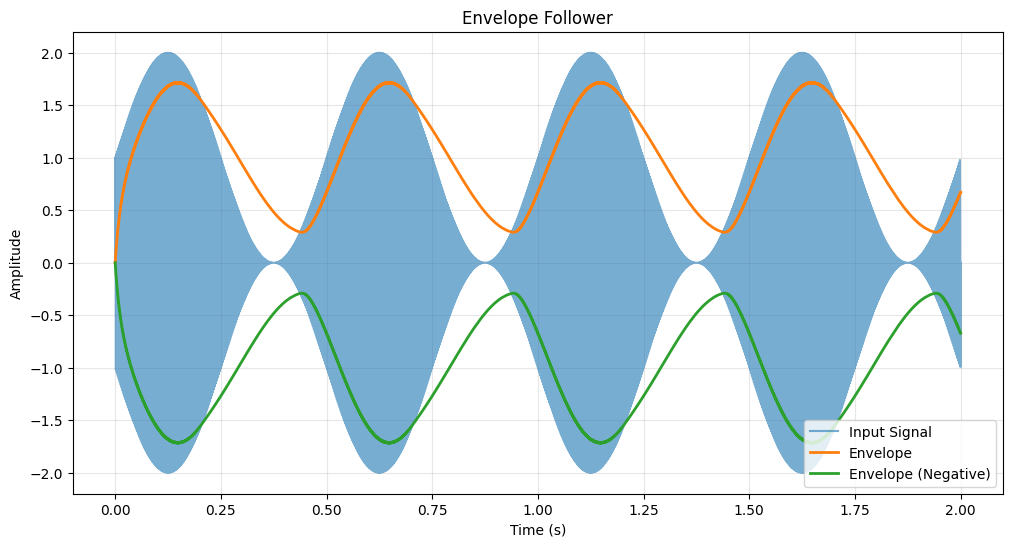

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Generate test signal (sine wave with modulation)
sample_rate = 44100
duration = 2
t = np.linspace(0, duration, int(sample_rate * duration))

# Modulated sine wave
signal = np.sin(2 * np.pi * 440 * t) * (1 + np.sin(2 * np.pi * 2 * t))

# Apply envelope follower
follower = EnvelopeFollower(attack_ms=10, release_ms=100, sample_rate=sample_rate)
envelope = follower.process_block(signal)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label='Input Signal', alpha=0.6)
plt.plot(t, envelope, label='Envelope', linewidth=2)
plt.plot(t, -np.array(envelope), label='Envelope (Negative)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Envelope Follower')
plt.show()
